In [1]:
import os
import sys
sys.path.append("..")
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc("svg", fonttype="none")
sns.set(context="talk", style="ticks")
from scipy import stats

from lib.finetune.model.esm2 import FinetunedEsmModel
from lib.finetune.model.esm2 import PretrainedEsmModel
from lib.predict.model.pll import compute_pseudo_loglikelihood

/home/kyoshida/.pyenv/versions/3.10.3/envs/esm2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Plot color
cols1 = sns.color_palette("Greys", 2)
cols2 = sns.color_palette("Oranges", 2)
cols3 = sns.color_palette("Blues", 2)

/home/kyoshida/.pyenv/versions/3.10.3/envs/esm2/lib/python3.10/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 382/382 [15:54<00:00,  2.50s/it]
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t

All keys matched successfully


100%|█████████████████████████████████████████████████████████████████████████████████| 382/382 [15:57<00:00,  2.51s/it]
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.weight', 'esm.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


All keys matched successfully


100%|██████████████████████████████████████████████████████████████████████████████████████████| 382/382 [16:02<00:00,  2.52s/it]


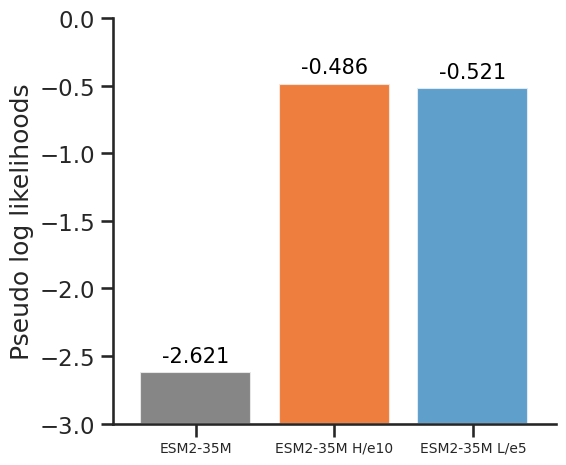

In [3]:
# Load data
df = pd.read_csv("../data/cytotoxicity/dataset.csv")
df = df[df.id != "wild-type"]


# Compute pseudo log-likelihood

# pretrained
model_name = "facebook/esm2_t12_35M_UR50D"
plm = PretrainedEsmModel(model_name)
pt_plls = [compute_pseudo_loglikelihood(seq, plm) for seq in tqdm(df.sequence.tolist())]
del plm


# finetuned with high-diversity sequences
ft_plm1 = FinetunedEsmModel(
    model_name=model_name,
    checkpoint_path="../results/finetuning/esm2_35M_high_batch128_constant_warmup0.0_lr5e-6/models/epoch10.pth",
    remove_suffix="module."
)
ft1_plls = [compute_pseudo_loglikelihood(seq, ft_plm1) for seq in tqdm(df.sequence.tolist())]
del ft_plm1


# finetuned with low-diversity sequences
ft_plm2 = FinetunedEsmModel(
    model_name=model_name,
    checkpoint_path="../results/finetuning/esm2_35M_low_batch64_constant_warmup0.0_lr5e-6/models/epoch5.pth",
    remove_suffix="module."
)
ft2_plls = [compute_pseudo_loglikelihood(seq, ft_plm2) for seq in tqdm(df.sequence.tolist())]
del ft_plm2


# SUmmarize scores
pll_score = pd.DataFrame({
    "pretrained": pt_plls,
    "finetuned_high": ft1_plls,
    "finetuned_low": ft2_plls,
})
pll_score.to_csv("../results/pseudo_loglikelihood/pll_scores.csv", index=False)


# Plot
offset = -3.0
xs = range(3)
ys = pll_score.mean(axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x=xs, height=ys-offset, color=[cols1[1], cols2[1], cols3[1]], width=0.8, alpha=0.8, bottom=offset)
for x, y in zip(xs, ys):
    ax.text(x, y+0.05, round(y, 3), ha='center', va='bottom', fontsize=15, color="black")
ax.set_xlim(-0.6, 2.6)
ax.set_ylim(-3.0, 0)
ax.set_xticks(xs)
ax.set_xticklabels(["ESM2-35M", "ESM2-35M H/e10", "ESM2-35M L/e5"], fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Pseudo log likelihoods")
sns.despine(top=True, bottom=False)
fig.tight_layout()
fig.savefig("./figures/pseudo_loglikelihood.svg")